# Decile portfolios from CNN predictions

In this section, I construct 10 decile portfolios from the model's predicted probability of an up move (`pred_prob_up`).

The logic is:

1. Use `end_date` as the portfolio formation date.
2. Compute the realized 5-day forward return from `close_now` and `close_future`.
3. On each rebalance date, sort all stocks into 10 deciles based on `pred_prob_up`.
4. Compute the equal-weight return of each decile.
5. Annualize the mean return and Sharpe ratio.

This follows the general setup in Jiang (2023) and my supervisor's paper, where stocks are sorted into decile portfolios using model predictions, the portfolios are equal-weighted, and held for five trading days.

In [25]:
import pandas as pd
import numpy as np
import os

## 1. Load the CSV and check the required columns

The file contains one row per stock-image observation.  
The most important columns here are:

- `end_date`: the date on which the image ends and the portfolio is formed
- `pred_prob_up`: the model's predicted probability that the future return is positive
- `close_now`: the close price at portfolio formation
- `close_future`: the close price 5 trading days later

I first load the data and make sure the required columns are present.

In [26]:
HEAD_FOLDER = "color_macd" # Change only once and run the entire program 


In [27]:
csv_path = os.path.join(HEAD_FOLDER, "predictions.csv")

df = pd.read_csv(csv_path)

required_cols = [
    "ticker", "end_date", "close_now", "close_future", "pred_prob_up"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Parse date
df["end_date"] = pd.to_datetime(df["end_date"])

# Keep only the columns we need here
df = df[["ticker", "end_date", "close_now", "close_future", "pred_prob_up"]].copy()

print(df.head())
print("\nNumber of rows:", len(df))
print("Number of unique end_date values:", df["end_date"].nunique())
print("Number of unique tickers:", df["ticker"].nunique())

   ticker   end_date  close_now  close_future  pred_prob_up
0   10078 2001-02-26    20.7500       20.9375      0.533493
1   10078 2001-03-05    20.9375       17.0625      0.501854
2   10078 2001-03-12    17.0625       19.0625      0.550147
3   10078 2001-03-19    19.0625       17.2400      0.550196
4   10078 2001-03-26    17.2400       15.1900      0.549379

Number of rows: 68721
Number of unique end_date values: 709
Number of unique tickers: 679


## 2. Compute the realized 5-day forward return

For each stock observation, I compute the realized holding-period return as

$$
R_{i,t \to t+5} = \frac{\text{close\_future}_{i,t}}{\text{close\_now}_{i,t}} - 1
$$

This is the return that each decile portfolio earns over the next 5 trading days.

In [28]:
# Basic cleaning
df = df.dropna(subset=["ticker", "end_date", "close_now", "close_future", "pred_prob_up"]).copy()
df = df[(df["close_now"] > 0) & (df["close_future"] > 0)].copy()

# Remove duplicate stock-date observations if any
df = df.sort_values(["end_date", "ticker"]).drop_duplicates(subset=["ticker", "end_date"])

# Realized 5-day forward return
df["forward_return_5d"] = df["close_future"] / df["close_now"] - 1

print(df[["ticker", "end_date", "close_now", "close_future", "pred_prob_up", "forward_return_5d"]].head())

     ticker   end_date  close_now  close_future  pred_prob_up  \
0     10078 2001-02-26    20.7500       20.9375      0.533493   
142   10104 2001-02-26    23.1875       17.0000      0.509864   
284   10107 2001-02-26    59.5625       57.4375      0.492771   
425   10108 2001-02-26    54.6000       57.3600      0.518408   
734   10145 2001-02-26    48.6800       45.6500      0.521580   

     forward_return_5d  
0             0.009036  
142          -0.266846  
284          -0.035677  
425           0.050549  
734          -0.062243  


## 3A. Choose rebalance dates when the raw windows overlap

In this case, the dataset contains observations on many consecutive trading days, so the
underlying 5-day windows overlap.

However, if I want portfolio returns that do **not** overlap across holding periods, I should
rebalance every 5th trading date. This gives a clean sequence of non-overlapping 5-day
portfolio returns.

In [29]:
# Sort unique formation dates
unique_dates = np.sort(df["end_date"].unique())

# Keep every 5th trading date so that portfolio holding periods do not overlap
rebalance_dates = unique_dates[::5]

weekly_df = df[df["end_date"].isin(rebalance_dates)].copy()

print("Total unique dates in full sample:", len(unique_dates))
print("Rebalance dates used:", len(rebalance_dates))
print("Rows after keeping every 5th date:", len(weekly_df))
print(weekly_df.head())

Total unique dates in full sample: 709
Rebalance dates used: 142
Rows after keeping every 5th date: 5401
     ticker   end_date  close_now  close_future  pred_prob_up  \
0     10078 2001-02-26    20.7500       20.9375      0.533493   
142   10104 2001-02-26    23.1875       17.0000      0.509864   
284   10107 2001-02-26    59.5625       57.4375      0.492771   
425   10108 2001-02-26    54.6000       57.3600      0.518408   
734   10145 2001-02-26    48.6800       45.6500      0.521580   

     forward_return_5d  
0             0.009036  
142          -0.266846  
284          -0.035677  
425           0.050549  
734          -0.062243  


## 3B. Choose rebalance dates when the data already has no 5-day overlap

In this case, the dataset is already constructed so that observations do not overlap across
the 5-day horizon.

Therefore, I can use **all available `end_date` values** as rebalance dates. No additional
subsampling is needed.

In [30]:
# Sort unique formation dates
unique_dates = np.sort(df["end_date"].unique())

# Use all dates, because the dataset is already non-overlapping
rebalance_dates = unique_dates

weekly_df = df[df["end_date"].isin(rebalance_dates)].copy()

print("Total unique dates in full sample:", len(unique_dates))
print("Rebalance dates used:", len(rebalance_dates))
print("Rows kept:", len(weekly_df))
print(weekly_df.head())

Total unique dates in full sample: 709
Rebalance dates used: 709
Rows kept: 68720
     ticker   end_date  close_now  close_future  pred_prob_up  \
0     10078 2001-02-26    20.7500       20.9375      0.533493   
142   10104 2001-02-26    23.1875       17.0000      0.509864   
284   10107 2001-02-26    59.5625       57.4375      0.492771   
425   10108 2001-02-26    54.6000       57.3600      0.518408   
734   10145 2001-02-26    48.6800       45.6500      0.521580   

     forward_return_5d  
0             0.009036  
142          -0.266846  
284          -0.035677  
425           0.050549  
734          -0.062243  


In [31]:
print("COLUMNS:")
print(weekly_df.columns.tolist())

print("\nINDEX NAMES:")
print(weekly_df.index.names)

COLUMNS:
['ticker', 'end_date', 'close_now', 'close_future', 'pred_prob_up', 'forward_return_5d']

INDEX NAMES:
[None]


In [32]:
print("Type:", type(weekly_df))
print("\nColumns as repr:")
print([repr(c) for c in weekly_df.columns])

print("\nIndex names:")
print(weekly_df.index.names)

print("\nDoes exact 'end_date' exist in columns?")
print("end_date" in weekly_df.columns)

Type: <class 'pandas.DataFrame'>

Columns as repr:
["'ticker'", "'end_date'", "'close_now'", "'close_future'", "'pred_prob_up'", "'forward_return_5d'"]

Index names:
[None]

Does exact 'end_date' exist in columns?
True


In [33]:
counts_per_date = weekly_df.groupby("end_date").size()
print(counts_per_date)


end_date
2001-02-26    441
2001-02-27      7
2001-02-28      5
2001-03-02      3
2001-03-05    436
             ... 
2003-12-17    333
2003-12-18     51
2003-12-19     35
2003-12-22     30
2003-12-23     37
Length: 709, dtype: int64


## 4. Assign stocks to 10 deciles on each rebalance date

On each `end_date`, I sort stocks by `pred_prob_up`:

- Decile 1 = lowest predicted probability of going up
- Decile 10 = highest predicted probability of going up

I use `pd.qcut()` to split the cross-section into 10 approximately equal-sized groups.

A small practical issue is that some stocks can have identical prediction values.  
To make `qcut()` stable, I first rank the predictions using `rank(method="first")`.

In [34]:
# Make sure end_date is a normal column, not an index
if "end_date" not in weekly_df.columns:
    weekly_df = weekly_df.reset_index()

# Make a safe copy of end_date to use for grouping
weekly_df["end_date_copy"] = weekly_df["end_date"]

# Keep only dates with at least 10 stocks, otherwise 10 deciles are impossible
counts_per_date = weekly_df.groupby("end_date_copy").size()
valid_dates = counts_per_date[counts_per_date >= 10].index

weekly_df = weekly_df[weekly_df["end_date_copy"].isin(valid_dates)].copy()

def assign_deciles_one_date(group):
    group = group.copy()

    # Rank first to avoid problems when many predictions are tied
    ranked = group["pred_prob_up"].rank(method="first")

    # Decile 1 = lowest prediction, Decile 10 = highest prediction
    group["decile"] = pd.qcut(ranked, q=10, labels=False) + 1
    return group

weekly_df = (
    weekly_df
    .groupby("end_date_copy", group_keys=False)
    .apply(assign_deciles_one_date)
    .reset_index(drop=True)
)

print(weekly_df.head(10))
print("\nNumber of rows:", len(weekly_df))

   ticker   end_date  close_now  close_future  pred_prob_up  \
0   10078 2001-02-26    20.7500       20.9375      0.533493   
1   10104 2001-02-26    23.1875       17.0000      0.509864   
2   10107 2001-02-26    59.5625       57.4375      0.492771   
3   10108 2001-02-26    54.6000       57.3600      0.518408   
4   10145 2001-02-26    48.6800       45.6500      0.521580   
5   10147 2001-02-26    45.0000       38.6000      0.525309   
6   10299 2001-02-26    48.8750       45.8125      0.545335   
7   10324 2001-02-26    89.5625       89.4375      0.496468   
8   10401 2001-02-26    21.8400       23.5600      0.465972   
9   10516 2001-02-26    15.5400       15.1800      0.551236   

   forward_return_5d  decile  
0           0.009036       8  
1          -0.266846       4  
2          -0.035677       2  
3           0.050549       6  
4          -0.062243       6  
5          -0.142222       7  
6          -0.062660       9  
7          -0.001396       2  
8           0.078755       

In [35]:
print("COLUMNS:")
print(list(weekly_df.columns))

print("\nINDEX NAME(S):")
print(weekly_df.index.names)

print("\nHEAD:")
print(weekly_df.head())

COLUMNS:
['ticker', 'end_date', 'close_now', 'close_future', 'pred_prob_up', 'forward_return_5d', 'decile']

INDEX NAME(S):
[None]

HEAD:
   ticker   end_date  close_now  close_future  pred_prob_up  \
0   10078 2001-02-26    20.7500       20.9375      0.533493   
1   10104 2001-02-26    23.1875       17.0000      0.509864   
2   10107 2001-02-26    59.5625       57.4375      0.492771   
3   10108 2001-02-26    54.6000       57.3600      0.518408   
4   10145 2001-02-26    48.6800       45.6500      0.521580   

   forward_return_5d  decile  
0           0.009036       8  
1          -0.266846       4  
2          -0.035677       2  
3           0.050549       6  
4          -0.062243       6  


In [36]:
# Quick diagnostic: number of stocks in each decile on each date
decile_counts = weekly_df.groupby(["end_date", "decile"]).size().unstack()
print(decile_counts.head())

decile      1   2   3   4   5   6   7   8   9   10
end_date                                          
2001-02-26  45  44  44  44  44  44  44  44  44  44
2001-03-05  44  44  43  44  43  44  43  44  43  44
2001-03-06   2   1   1   1   1   1   1   1   1   1
2001-03-12  44  44  43  44  44  43  44  43  44  44
2001-03-19  44  44  43  44  43  44  43  44  43  44


## 5. Compute equal-weight decile returns on each rebalance date

For each formation date and decile, I take the simple average of the realized 5-day forward returns across all stocks in that decile.

This gives me one 5-day portfolio return for each decile on each rebalance date.

In [37]:
decile_returns_by_date = (
    weekly_df
    .groupby(["end_date", "decile"])["forward_return_5d"]
    .mean()
    .reset_index()
    .sort_values(["end_date", "decile"])
)

print(decile_returns_by_date.head(15))

     end_date  decile  forward_return_5d
0  2001-02-26       1          -0.022795
1  2001-02-26       2          -0.035893
2  2001-02-26       3          -0.017355
3  2001-02-26       4          -0.020849
4  2001-02-26       5          -0.023776
5  2001-02-26       6          -0.019921
6  2001-02-26       7          -0.012338
7  2001-02-26       8          -0.034519
8  2001-02-26       9          -0.001149
9  2001-02-26      10          -0.000693
10 2001-03-05       1          -0.032917
11 2001-03-05       2          -0.029028
12 2001-03-05       3          -0.027404
13 2001-03-05       4          -0.040033
14 2001-03-05       5          -0.045679


## 6. Put the decile returns into wide format and construct High-minus-Low

Now I reshape the data so that each column is one decile:

- column 1 = Low
- column 10 = High

Then I create the spread portfolio:

$$H-L = \text{Decile 10} - \text{Decile 1}$$

This is the same long-short spread that is reported in the papers.

In [38]:
decile_matrix = decile_returns_by_date.pivot(
    index="end_date",
    columns="decile",
    values="forward_return_5d"
).sort_index()

# Add High-minus-Low spread
decile_matrix["H-L"] = decile_matrix[10] - decile_matrix[1]

# Optional: rename columns for nicer display
decile_matrix = decile_matrix.rename(columns={1: "Low", 10: "High"})

print(decile_matrix.head())

decile           Low         2         3         4         5         6  \
end_date                                                                 
2001-02-26 -0.022795 -0.035893 -0.017355 -0.020849 -0.023776 -0.019921   
2001-03-05 -0.032917 -0.029028 -0.027404 -0.040033 -0.045679 -0.049501   
2001-03-06 -0.083525  0.023160 -0.178358  0.002394 -0.039192 -0.116691   
2001-03-12 -0.025697 -0.025549 -0.028182 -0.010175 -0.015444 -0.013220   
2001-03-19 -0.020982 -0.024988 -0.003812 -0.024621 -0.025533 -0.024886   

decile             7         8         9      High       H-L  
end_date                                                      
2001-02-26 -0.012338 -0.034519 -0.001149 -0.000693  0.022101  
2001-03-05 -0.036089 -0.050499 -0.071163 -0.070777 -0.037860  
2001-03-06  0.004494 -0.131687  0.009967 -0.018511  0.065014  
2001-03-12 -0.003602  0.017728 -0.003133 -0.003854  0.021843  
2001-03-19 -0.035137 -0.022785 -0.021441 -0.007803  0.013179  


## 7. Compute annualized return and annualized Sharpe ratio

Each row in `decile_matrix` is a **5-trading-day portfolio return**.

So I annualize using:

$$
\text{periods per year} = \frac{252}{5}
$$

Then:

$$
\text{Annualized Return} = \bar{r}_{5d} \times \frac{252}{5}
$$

$$
\text{Annualized Sharpe} = \frac{\bar{r}_{5d}}{\sigma_{5d}} \times \sqrt{\frac{252}{5}}
$$

This is the standard way to annualize fixed-horizon portfolio returns.

In [39]:
periods_per_year = 252 / 5  # 5-trading-day holding period

def annualized_stats(return_series):
    s = pd.Series(return_series).dropna()
    
    mean_5d = s.mean()
    std_5d = s.std(ddof=1)
    
    ann_return = mean_5d * periods_per_year
    
    if std_5d == 0 or np.isnan(std_5d):
        ann_sharpe = np.nan
    else:
        ann_sharpe = (mean_5d / std_5d) * np.sqrt(periods_per_year)
    
    return pd.Series({
        "Mean_5d_Return": mean_5d,
        "Std_5d_Return": std_5d,
        "Annualized_Return": ann_return,
        "Annualized_Sharpe": ann_sharpe,
        "N_periods": len(s)
    })

summary = decile_matrix.apply(annualized_stats, axis=0).T
summary

,Mean_5d_Return,Std_5d_Return,Annualized_Return,Annualized_Sharpe,N_periods
decile,,,,,
Low,-0.000045,0.039152,-0.002243,-0.008070,679.0
2,0.001369,0.040386,0.068985,0.240611,679.0
3,-0.002483,0.048490,-0.125161,-0.363583,679.0
4,-0.000433,0.044716,-0.021845,-0.068815,679.0
5,0.001985,0.043439,0.100049,0.324425,679.0
6,0.003184,0.044502,0.160472,0.507928,679.0
7,0.002825,0.047011,0.142399,0.426675,679.0
8,0.004891,0.051084,0.246512,0.679737,679.0
9,0.003978,0.045791,0.200495,0.616750,679.0


## 8. Make the final table look like the paper

To make the output easier to compare with the paper tables, I keep only the annualized return and annualized Sharpe ratio, and I convert the return to percent.

In [40]:
final_table = summary[["Annualized_Return", "Annualized_Sharpe", "N_periods"]].copy()
final_table["Annualized_Return_pct"] = final_table["Annualized_Return"] * 100

# Put columns in a nicer order
final_table = final_table[["Annualized_Return_pct", "Annualized_Sharpe", "N_periods"]]

# Optional: reorder rows
desired_order = ["Low", 2, 3, 4, 5, 6, 7, 8, 9, "High", "H-L"]
final_table = final_table.reindex([x for x in desired_order if x in final_table.index])

print(final_table.round(4))

        Annualized_Return_pct  Annualized_Sharpe  N_periods
decile                                                     
Low                   -0.2243            -0.0081      679.0
2                      6.8985             0.2406      679.0
3                    -12.5161            -0.3636      679.0
4                     -2.1845            -0.0688      679.0
5                     10.0049             0.3244      679.0
6                     16.0472             0.5079      679.0
7                     14.2399             0.4267      679.0
8                     24.6512             0.6797      679.0
9                     20.0495             0.6168      679.0
High                  56.0799             1.6013      679.0
H-L                   56.3042             1.6590      679.0


## 9. Interpretation of the output

The final table should be read as follows:

- `Low` is the decile with the lowest predicted probability of an up move.
- `High` is the decile with the highest predicted probability of an up move.
- `H-L` is a long-short strategy that buys the highest decile and shorts the lowest decile.
- `Annualized_Return_pct` is the annualized mean return in percent.
- `Annualized_Sharpe` is the annualized Sharpe ratio.

If the model is useful, I should generally see returns and Sharpe ratios improve as I move from `Low` to `High`.

In [41]:
# Average number of stocks in each decile
avg_names_per_decile = (
    weekly_df.groupby(["end_date", "decile"]).size()
    .groupby("decile")
    .mean()
)

print("Average number of stocks per decile:")
print(avg_names_per_decile.round(2))

# Check monotonicity visually
display_cols = [c for c in ["Low", 2, 3, 4, 5, 6, 7, 8, 9, "High", "H-L"] if c in decile_matrix.columns]
display(decile_matrix[display_cols].head())

Average number of stocks per decile:
decile
1     10.53
2     10.05
3      9.95
4     10.05
5     10.16
6      9.81
7      9.95
8     10.04
9      9.95
10    10.42
dtype: float64


decile,Low,2,3,4,5,6,7,8,9,High,H-L
end_date,,,,,,,,,,,
2001-02-26,-0.022795,-0.035893,-0.017355,-0.020849,-0.023776,-0.019921,-0.012338,-0.034519,-0.001149,-0.000693,0.022101
2001-03-05,-0.032917,-0.029028,-0.027404,-0.040033,-0.045679,-0.049501,-0.036089,-0.050499,-0.071163,-0.070777,-0.037860
2001-03-06,-0.083525,0.023160,-0.178358,0.002394,-0.039192,-0.116691,0.004494,-0.131687,0.009967,-0.018511,0.065014
2001-03-12,-0.025697,-0.025549,-0.028182,-0.010175,-0.015444,-0.013220,-0.003602,0.017728,-0.003133,-0.003854,0.021843
2001-03-19,-0.020982,-0.024988,-0.003812,-0.024621,-0.025533,-0.024886,-0.035137,-0.022785,-0.021441,-0.007803,0.013179


## Always-long equal-weight benchmark

As a reference benchmark, I also calculate the performance of an **always-long, equal-weight portfolio across all stocks**.

This benchmark does **not** sort stocks into deciles.  
Instead, on each portfolio formation date, it simply buys **all available stocks** and assigns each stock the same weight.

That is why this benchmark produces only **one portfolio return series**, and therefore only **one annualized return** and **one Sharpe ratio**.

### Step 1: Compute the 5-day forward return for each stock

For each stock $i$ on formation date $t$, the realized 5-day forward return is:

$$
r_{i,t} = \frac{\text{close\_future}_{i,t}}{\text{close\_now}_{i,t}} - 1
$$

where:

- $\text{close\_now}_{i,t}$ is the closing price at the portfolio formation date
- $\text{close\_future}_{i,t}$ is the closing price 5 trading days later

### Step 2: Compute the equal-weight benchmark return on each date

On each formation date $t$, the always-long benchmark return is the simple average of all stock returns on that date:

$$
r^{EW}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} r_{i,t}
$$

where $N_t$ is the number of available stocks on date $t$.

So instead of creating 10 decile portfolios, I create only **one** portfolio each period:

- long all stocks
- equal weight each stock
- hold for 5 trading days

This gives a time series of benchmark returns:

$$
r^{EW}_{t_1}, r^{EW}_{t_2}, r^{EW}_{t_3}, \dots
$$

### Step 3: Annualize the mean return

Because each portfolio is held for 5 trading days, the number of holding periods per year is approximately:

$$
\frac{252}{5}
$$

where 252 is the standard number of trading days in a year.

The annualized return is therefore:

$$
\text{Annualized Return} = \bar{r}_{5d} \times \frac{252}{5}
$$

where $\bar{r}_{5d}$ is the average 5-day benchmark return across all periods.

### Step 4: Annualize the Sharpe ratio

The Sharpe ratio measures return relative to volatility.

Let $\sigma_{5d}$ denote the standard deviation of the 5-day benchmark returns.  
Then the annualized Sharpe ratio is:

$$
\text{Annualized Sharpe} = \frac{\bar{r}_{5d}}{\sigma_{5d}} \times \sqrt{\frac{252}{5}}
$$

### Why does this benchmark only give one return and one Sharpe ratio?

The decile analysis gives many values because stocks are split into many portfolios:

- Decile 1
- Decile 2
- ...
- Decile 10
- High-minus-Low

So each decile has its own return series and its own Sharpe ratio.

In contrast, the always-long benchmark does **not** split stocks into groups.  
It simply averages all stocks into one equal-weight portfolio on each date.

Therefore, it produces:

- one portfolio return series
- one annualized return
- one annualized Sharpe ratio

### Interpretation

This benchmark is useful because it shows how well a simple passive strategy performs without using the model.

If the model is useful in a long-only sense, then the **High decile** should ideally outperform this benchmark in terms of:

- annualized return
- Sharpe ratio

If the model is useful as a ranking model, then returns should generally improve from the **Low** decile to the **High** decile, and the **High-minus-Low** spread should be positive and economically meaningful.

In [42]:
# Always-long benchmark using the SAME sample as the decile portfolios

benchmark_df = weekly_df.copy()

benchmark_df["end_date"] = pd.to_datetime(benchmark_df["end_date"])
benchmark_df = benchmark_df.dropna(subset=["end_date", "forward_return_5d"])

ew_returns = (
    benchmark_df
    .groupby("end_date")["forward_return_5d"]
    .mean()
    .sort_index()
)

# Make sure it uses exactly the same dates as decile_matrix
ew_returns = ew_returns.reindex(decile_matrix.index).dropna()

periods_per_year = 252 / 5

annualized_return = ew_returns.mean() * periods_per_year
annualized_sharpe = (
    ew_returns.mean() / ew_returns.std(ddof=1)
) * np.sqrt(periods_per_year)

print("Always-long equal-weight benchmark, same sample as deciles")
print(f"Annualized return: {annualized_return:.4f}  ({annualized_return*100:.2f}%)")
print(f"Annualized Sharpe: {annualized_sharpe:.4f}")
print(f"Number of periods: {len(ew_returns)}")

Always-long equal-weight benchmark, same sample as deciles
Annualized return: 0.1387  (13.87%)
Annualized Sharpe: 0.6058
Number of periods: 679


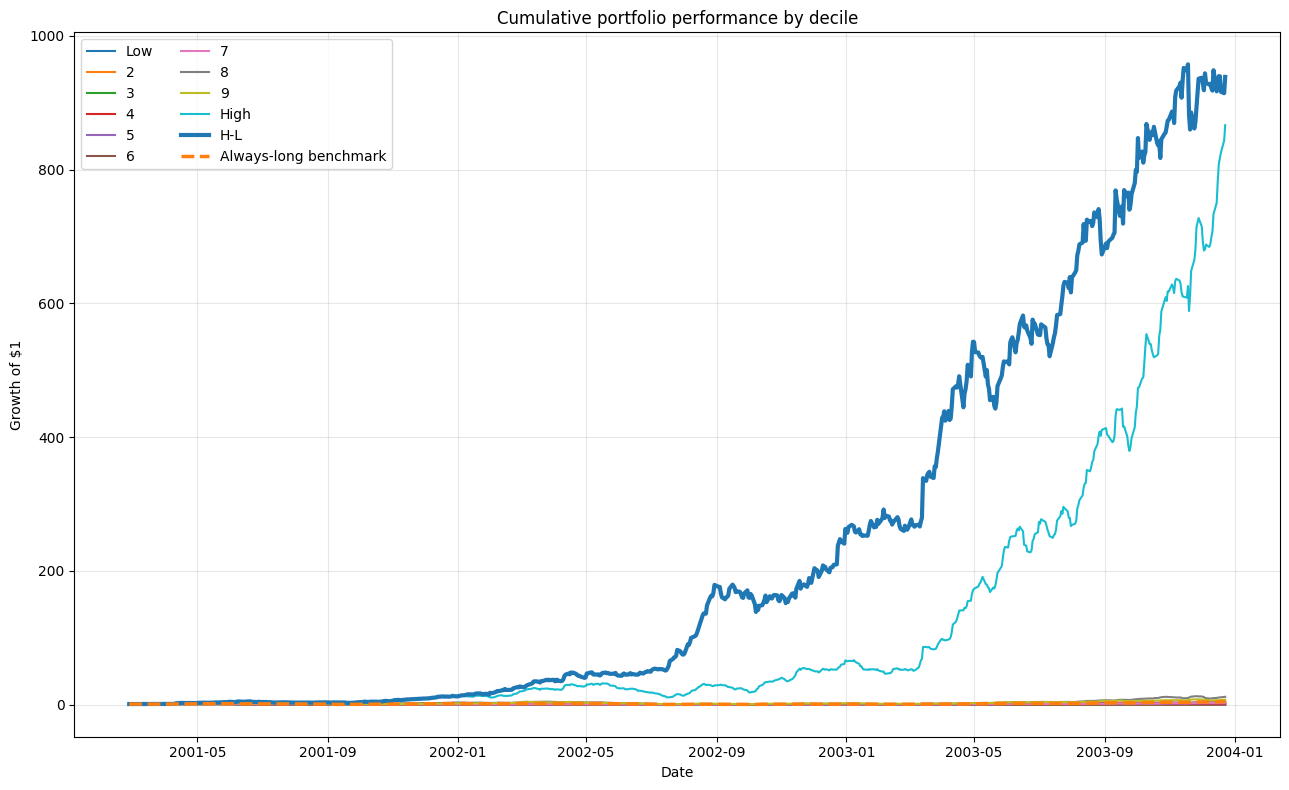

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Cumulative returns plot for all deciles
# Uses objects already created above:
#   decile_matrix
#   ew_returns
# --------------------------------------------------

plot_df = decile_matrix.copy()
bench = ew_returns.copy()

# Make sure index is datetime and sorted
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

bench.index = pd.to_datetime(bench.index)
bench = bench.sort_index()

# Keep benchmark on same dates
bench = bench.reindex(plot_df.index)

# Cumulative growth of 1 invested
cum_df = (1 + plot_df).cumprod()
cum_bench = (1 + bench).cumprod()

# Order columns nicely if they exist
ordered_cols = [c for c in ["Low", 2, 3, 4, 5, 6, 7, 8, 9, "High", "H-L"] if c in cum_df.columns]

plt.figure(figsize=(13, 8))

for col in ordered_cols:
    if col == "H-L":
        plt.plot(cum_df.index, cum_df[col], linewidth=3, label="H-L")
    else:
        plt.plot(cum_df.index, cum_df[col], linewidth=1.5, label=str(col))

# Always-long benchmark
plt.plot(
    cum_bench.index,
    cum_bench,
    linestyle="--",
    linewidth=2.5,
    label="Always-long benchmark"
)

plt.title("Cumulative portfolio performance by decile")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

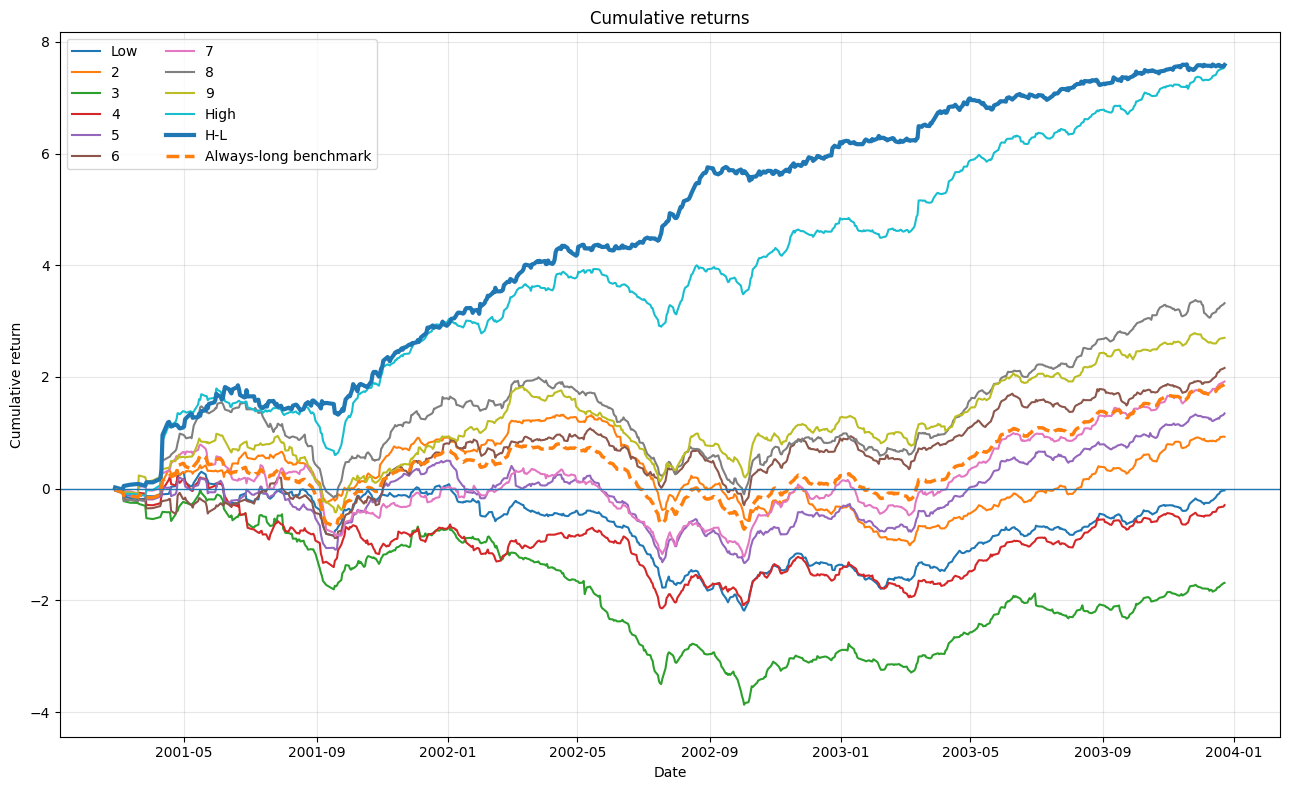

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Cumulative plot closest to supervisor style
# Uses cumulative SUM of period returns
# --------------------------------------------------

plot_df = decile_matrix.copy()
bench = ew_returns.copy()

# Make sure index is datetime and sorted
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

bench.index = pd.to_datetime(bench.index)
bench = bench.sort_index()
bench = bench.reindex(plot_df.index)

# Cumulative summed returns
cum_df = plot_df.cumsum()
cum_bench = bench.cumsum()

# Order columns nicely if they exist
ordered_cols = [c for c in ["Low", 2, 3, 4, 5, 6, 7, 8, 9, "High", "H-L"] if c in cum_df.columns]

plt.figure(figsize=(13, 8))

for col in ordered_cols:
    if col == "H-L":
        plt.plot(cum_df.index, cum_df[col], linewidth=3, label="H-L")
    else:
        plt.plot(cum_df.index, cum_df[col], linewidth=1.5, label=str(col))

plt.plot(
    cum_bench.index,
    cum_bench,
    linestyle="--",
    linewidth=2.5,
    label="Always-long benchmark"
)

plt.axhline(0, linewidth=1)
plt.title("Cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

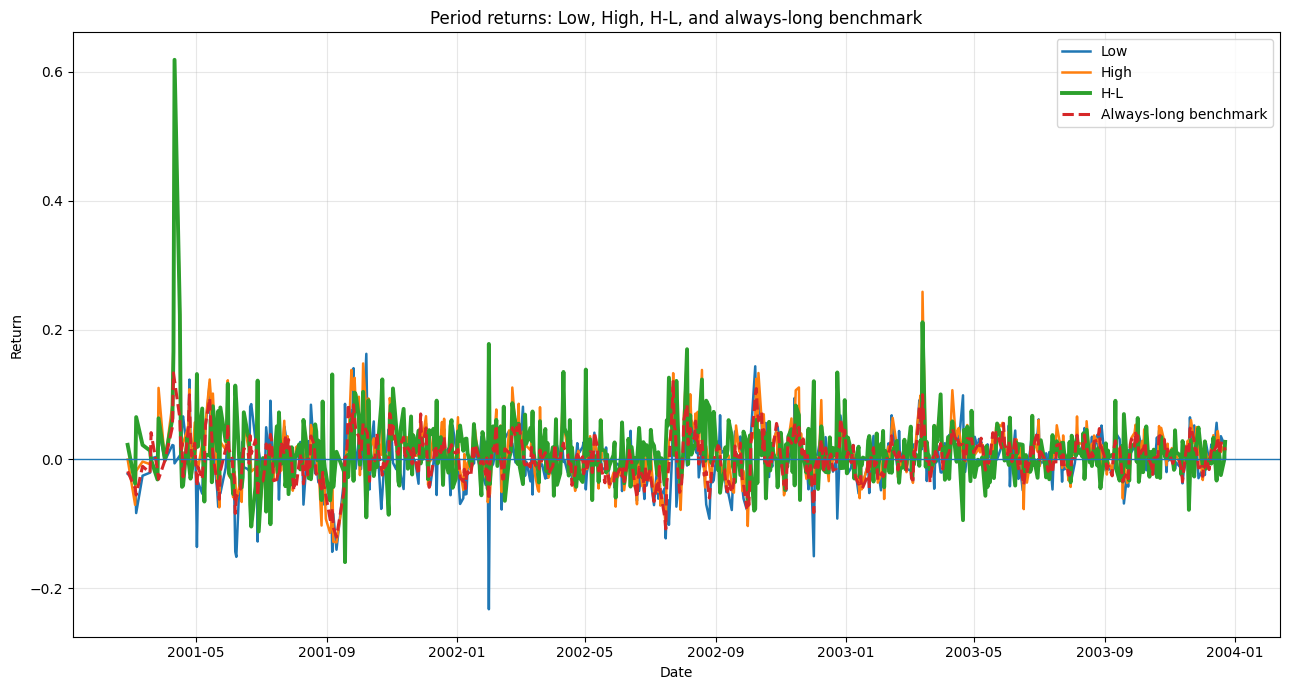

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Non-cumulative returns plot:
# Low, High, H-L, and always-long benchmark
# Uses:
#   decile_matrix
#   ew_returns
# --------------------------------------------------

plot_df = decile_matrix.copy()
bench = ew_returns.copy()

# Make sure index is datetime and sorted
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.sort_index()

bench.index = pd.to_datetime(bench.index)
bench = bench.sort_index()

# Keep benchmark on same dates
bench = bench.reindex(plot_df.index)

plt.figure(figsize=(13, 7))

if "Low" in plot_df.columns:
    plt.plot(plot_df.index, plot_df["Low"], linewidth=1.8, label="Low")

if "High" in plot_df.columns:
    plt.plot(plot_df.index, plot_df["High"], linewidth=1.8, label="High")

if "H-L" in plot_df.columns:
    plt.plot(plot_df.index, plot_df["H-L"], linewidth=2.8, label="H-L")

plt.plot(
    bench.index,
    bench,
    linestyle="--",
    linewidth=2.2,
    label="Always-long benchmark"
)

plt.axhline(0, linewidth=1)
plt.title("Period returns: Low, High, H-L, and always-long benchmark")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
import pandas as pd
import numpy as np
from scipy import stats

# --------------------------------------------------
# t-test / p-value table for deciles
# Uses:
#   decile_matrix
# --------------------------------------------------

# Safe copy
test_df = decile_matrix.copy()

# Make sure dates are sorted
test_df.index = pd.to_datetime(test_df.index)
test_df = test_df.sort_index()

# Nice row order
row_order = [c for c in ["Low", 2, 3, 4, 5, 6, 7, 8, 9, "High", "H-L"] if c in test_df.columns]

rows = []
for col in row_order:
    s = pd.to_numeric(test_df[col], errors="coerce").dropna()

    # one-sample t-test: mean return = 0
    t_stat, p_val = stats.ttest_1samp(s, popmean=0.0, nan_policy="omit")

    rows.append({
        "Decile": str(col),
        "t": t_stat,
        "p": p_val
    })

t_table = pd.DataFrame(rows).set_index("Decile")
t_table = t_table.round(4)
t_table.columns = pd.MultiIndex.from_product([["All"], t_table.columns])

display(t_table)

All        
             t       p
Decile                
Low    -0.0296  0.9764
2       0.8831  0.3775
3      -1.3345  0.1825
4      -0.2526  0.8007
5       1.1908  0.2342
6       1.8643  0.0627
7       1.5661  0.1178
8       2.4949  0.0128
9       2.2638  0.0239
High    5.8774  0.0000
H-L     6.0894  0.0000